# HyPlan Tutorial: End-to-End Airborne Campaign Planning

This notebook demonstrates a complete workflow for planning an airborne imaging spectroscopy campaign using **HyPlan**. We will:

1. Define an instrument and aircraft
2. Create individual flight lines
3. Generate a flight box over a study area
4. Check solar illumination constraints
5. Find nearby airports
6. Optimize the flight line sequence
7. Compute a detailed flight plan
8. Visualize the results

The study area is **Santa Rosa Island**, one of the Channel Islands off the coast of Southern California — a region frequently surveyed by NASA airborne science campaigns.

In [67]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import hyplan
from hyplan import (
    FlightLine, box_around_polygon,
    DynamicAviation_B200, AVIRIS3,
    Airport, initialize_data, airports_within_radius,
    compute_flight_plan, plot_flight_plan, plot_altitude_trajectory,
    build_graph, greedy_optimize,
    generate_swath_polygon, calculate_swath_widths,
    map_flight_lines, ureg,
)
from hyplan.sun import solar_threshold_times, solar_position_increments
from hyplan.geometry import haversine

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import shape
import json

## 1. Define the Instrument and Aircraft

We will use **AVIRIS-3**, NASA's next-generation imaging spectrometer, flown on a **Beechcraft King Air B200** operated by Dynamic Aviation.

In [68]:
sensor = AVIRIS3()
aircraft = DynamicAviation_B200()

print(f"Sensor:   {sensor.name}")
print(f"  FOV:    {sensor.fov}°")
print(f"  Pixels: {sensor.across_track_pixels} across-track")
print(f"  Rate:   {sensor.frame_rate}")
print()
print(f"Aircraft: {aircraft.aircraft_type}")
print(f"  Cruise: {aircraft.cruise_speed}")
print(f"  Ceiling: {aircraft.service_ceiling}")

Sensor:   AVIRIS 3
  FOV:    39.6°
  Pixels: 1234 across-track
  Rate:   216 hertz

Aircraft: King Air 200
  Cruise: 250 knot
  Ceiling: 35000 foot


### Sensor Performance at Altitude

AVIRIS-3's spatial resolution and swath width depend on the flight altitude above ground level (AGL). Let's examine how these vary.

In [69]:
altitudes_ft = [5000, 10000, 15000, 20000, 25000]
print(f"{'Altitude (ft)':>14s}  {'GSD (m)':>8s}  {'Swath (km)':>10s}")
print("-" * 36)
for alt_ft in altitudes_ft:
    alt = ureg.Quantity(alt_ft, "feet")
    gsd = sensor.ground_sample_distance(alt).to(ureg.meter)
    swath = sensor.swath_width(alt).to(ureg.kilometer)
    print(f"{alt_ft:>14d}  {gsd.magnitude:>8.2f}  {swath.magnitude:>10.2f}")

 Altitude (ft)   GSD (m)  Swath (km)
------------------------------------
          5000      0.85        1.10
         10000      1.71        2.19
         15000      2.56        3.29
         20000      3.41        4.39
         25000      4.27        5.49


## 2. Define the Study Area

We load the Santa Rosa Island polygon from a GeoJSON file included in the repository.

Study area centroid: 33.3821°N, -118.4332°W
Bounding box: (-118.6064373, 33.2987495, -118.3035159, 33.479031)


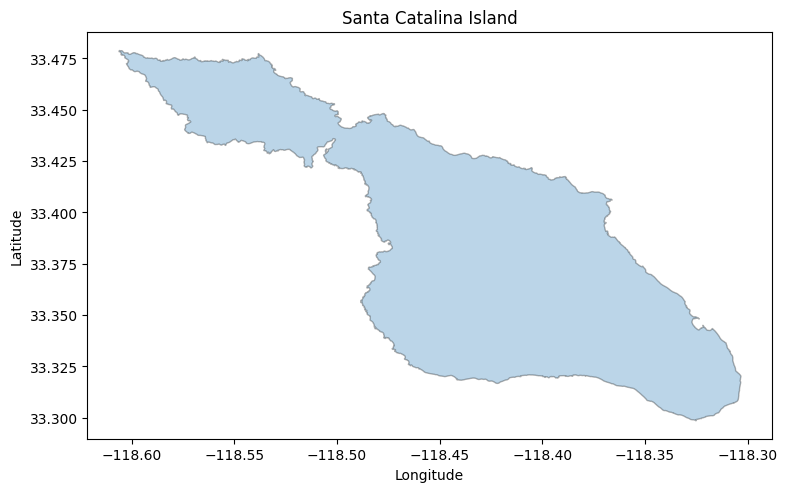

In [70]:
with open("../notebooks/exampledata/catalina.geojson") as f:
    geojson = json.load(f)

study_area = shape(geojson["features"][0]["geometry"])
centroid = study_area.centroid

print(f"Study area centroid: {centroid.y:.4f}°N, {centroid.x:.4f}°W")
print(f"Bounding box: {study_area.bounds}")

# Quick plot
fig, ax = plt.subplots(figsize=(8, 5))
gpd.GeoSeries([study_area]).plot(ax=ax, alpha=0.3, edgecolor="black")
ax.set_title("Santa Catalina Island")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

## 3. Generate Flight Lines

We use `box_around_polygon` to automatically generate parallel flight lines covering the island, with 20% swath overlap between adjacent lines. The function determines the optimal heading from the minimum rotated rectangle of the polygon.

In [71]:
flight_altitude = ureg.Quantity(20000, "feet")

flight_lines = box_around_polygon(
    instrument=sensor,
    altitude_msl=flight_altitude,
    polygon=study_area,
    box_name="SRI",
    overlap=20.0,
    alternate_direction=True,
    clip_to_polygon=False,
)

print(f"Generated {len(flight_lines)} flight lines at {flight_altitude}")
for fl in flight_lines:
    print(f"  {fl.site_name}: length={fl.length.to(ureg.kilometer):.1f}, azimuth={fl.az12.magnitude:.1f}°")

Generated 5 flight lines at 20000 foot
  SRI_L01_FL200: length=33.4 kilometer, azimuth=295.6°
  SRI_L02_FL200: length=33.4 kilometer, azimuth=115.4°
  SRI_L03_FL200: length=33.4 kilometer, azimuth=295.5°
  SRI_L04_FL200: length=33.4 kilometer, azimuth=115.4°
  SRI_L05_FL200: length=33.5 kilometer, azimuth=295.5°


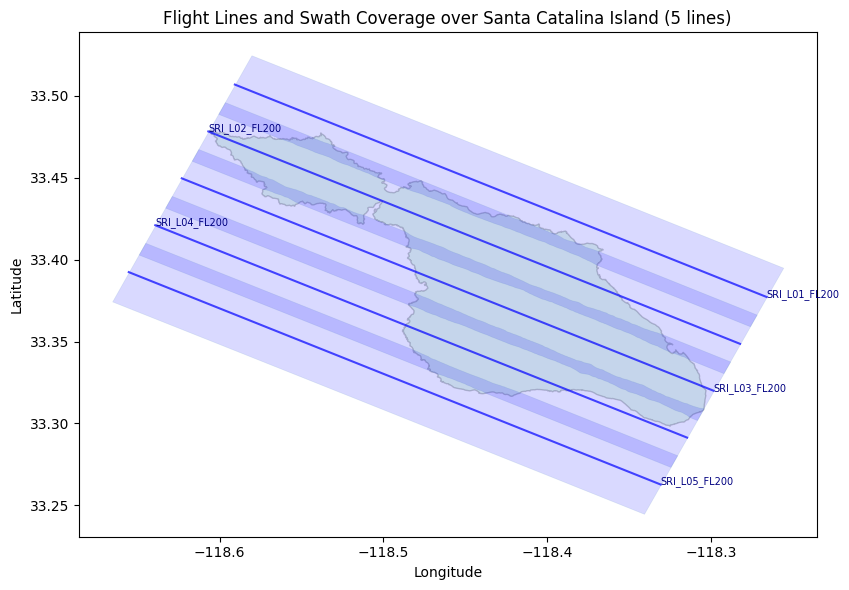

In [72]:
# Plot flight lines with swath polygons over the study area
fig, ax = plt.subplots(figsize=(10, 6))
gpd.GeoSeries([study_area]).plot(ax=ax, alpha=0.2, edgecolor="black", color="lightgreen")

for fl in flight_lines:
    # Draw swath polygon
    swath = generate_swath_polygon(fl, sensor)
    gpd.GeoSeries([swath]).plot(ax=ax, alpha=0.15, color="blue", edgecolor="steelblue", linewidth=0.5)
    # Draw flight line
    x, y = fl.geometry.xy
    ax.plot(x, y, "b-", linewidth=1.5, alpha=0.7)
    ax.annotate(fl.site_name, xy=(x[0], y[0]), fontsize=7, color="navy")

ax.set_title(f"Flight Lines and Swath Coverage over Santa Catalina Island ({len(flight_lines)} lines)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

### Swath Geometry

Compute the ground swath footprint for one of the flight lines to verify coverage.

In [73]:
# Compute swath for the first flight line
swath_poly = generate_swath_polygon(flight_lines[0], sensor)
widths = calculate_swath_widths(swath_poly)

print(f"Swath widths for {flight_lines[0].site_name}:")
print(f"  Min:  {widths['min_width']:.0f} m")
print(f"  Mean: {widths['mean_width']:.0f} m")
print(f"  Max:  {widths['max_width']:.0f} m")

# Compare with theoretical swath width
theoretical = sensor.swath_width(flight_altitude).to(ureg.meter).magnitude
print(f"\nTheoretical swath width at {flight_altitude}: {theoretical:.0f} m")

Swath widths for SRI_L01_FL200:
  Min:  4250 m
  Mean: 4358 m
  Max:  4389 m

Theoretical swath width at 20000 foot: 4389 m


## 4. Check Solar Illumination

Imaging spectrometers require adequate solar illumination. We compute solar elevation times to determine the usable data-collection window.

In [74]:
# Solar elevation thresholds: 30° (minimum usable) and 50° (ideal)
solar_times = solar_threshold_times(
    latitude=centroid.y,
    longitude=centroid.x,
    start_date="2025-06-15",
    end_date="2025-06-20",
    thresholds=[30, 50],
    timezone_offset=-7,  # PDT
)

print("Solar threshold times (PDT):")
print(solar_times.to_string(index=False))

Solar threshold times (PDT):
      Date  Rise_30  Rise_50   Set_50   Set_30
2025-06-15 08:21:00 09:57:00 15:51:00 17:28:00
2025-06-16 08:21:00 09:57:00 15:52:00 17:28:00
2025-06-17 08:21:00 09:58:00 15:52:00 17:28:00
2025-06-18 08:21:00 09:58:00 15:52:00 17:29:00
2025-06-19 08:22:00 09:58:00 15:52:00 17:29:00
2025-06-20 08:22:00 09:58:00 15:53:00 16:59:00


In [75]:
# Detailed solar positions on June 15
positions = solar_position_increments(
    latitude=centroid.y,
    longitude=centroid.x,
    date="2025-06-15",
    min_elevation=20,
    timezone_offset=-7,
    increment="30min",
)

print("Solar positions on June 15, 2025 (elevation > 20°):")
print(positions.to_string(index=False))

Solar positions on June 15, 2025 (elevation > 20°):
    Time    Azimuth  Elevation
17:00:00 276.292608  35.764064
17:30:00 279.859738  29.571992
18:00:00 283.362522  23.448536
08:00:00  77.956344  25.799102
08:30:00  81.469279  31.951967
09:00:00  85.084185  38.164444
09:30:00  88.926074  44.412613
10:00:00  93.181069  50.669085
10:30:00  98.154835  56.896813
11:00:00 104.403050  63.035723
11:30:00 113.050720  68.968408
12:00:00 126.608617  74.417988
12:30:00 150.416778  78.628881
13:00:00 187.399862  79.886148
13:30:00 220.210579  77.277293
14:00:00 239.344582  72.455886
14:30:00 250.611725  66.773168
15:00:00 258.163899  60.742993
15:30:00 263.842145  54.561586
16:00:00 268.498255  48.318205
16:30:00 272.570577  42.061865


## 5. Find Nearby Airports

We need airports for takeoff, landing, and potential refueling stops.

In [76]:
# Initialize airport database for the US
initialize_data(countries=["US"])

# Find airports within 150 km of the study area
nearby = airports_within_radius(
    centroid.y, centroid.x,
    radius=150,
    unit="kilometers",
    return_details=True,
)

nearby["distance_km"] = nearby["distance_m"] / 1000.0

print(f"Found {len(nearby)} airports within 150 km:")
print(nearby[["icao_code", "name", "municipality", "distance_km"]].head(10).to_string(index=False))

Found 53 airports within 150 km:
icao_code                                              name        municipality  distance_km
     KAVX                                  Catalina Airport              Avalon     3.001566
     KNUC San Clemente Island Naval Auxiliary Landing Field San Clemente Island    42.474291
     KTOA                                   Zamperini Field            Torrance    47.639764
     KLGB                  Long Beach International Airport          Long Beach    54.977377
     KSLI                       Los Alamitos Army Air Field        Los Alamitos    57.656498
     KCPM                           Compton Woodley Airport             Compton    59.134582
     KHHR   Jack Northrop Field Hawthorne Municipal Airport           Hawthorne    60.810731
     KSNA    John Wayne Orange County International Airport           Santa Ana    61.596349
     KLAX                 Los Angeles International Airport         Los Angeles    62.361719
     KFUL                       Fulle

In [77]:
# Select departure and return airports
departure_airport = Airport("KSBA")  # Santa Barbara
return_airport = Airport("KSBA")

# Additional refueling option
refuel_airport = Airport("KOXR")  # Oxnard (Ventura County)

airports = [departure_airport, refuel_airport]

print(f"Departure: {departure_airport.name} ({departure_airport.icao_code})")
print(f"  Location: {departure_airport.latitude:.4f}°N, {departure_airport.longitude:.4f}°W")
print(f"  Elevation: {departure_airport.elevation_ft:.0f} ft")
print(f"\nRefuel option: {refuel_airport.name} ({refuel_airport.icao_code})")

Departure: Santa Barbara Municipal Airport (KSBA)
  Location: 34.4262°N, -119.8400°W
  Elevation: 13 ft

Refuel option: Oxnard Airport (KOXR)


## 6. Optimize Flight Line Sequence

The greedy optimizer finds an efficient ordering of flight lines that minimizes total transit time, respecting aircraft endurance and daily flight-time limits.

In [78]:
result = greedy_optimize(
    aircraft=aircraft,
    flight_lines=flight_lines,
    airports=airports,
    takeoff_airport=departure_airport,
    return_airport=return_airport,
    max_endurance=4.5,           # hours per sortie
    max_daily_flight_time=8.0,   # hours per day
    max_days=3,
)

print(f"Optimization result:")
print(f"  Lines covered: {result['lines_covered']}/{len(flight_lines)}")
print(f"  Total time:    {result['total_time']:.2f} hours")
print(f"  Days used:     {result['days_used']}")
for i, dt in enumerate(result["daily_times"], 1):
    print(f"    Day {i}: {dt:.2f} hours")
print(f"  Refuel stops:  {result['refuel_stops']}")
print(f"\nRoute: {' → '.join(result['route'])}")

Optimization result:
  Lines covered: 5/5
  Total time:    1.60 hours
  Days used:     1
    Day 1: 1.60 hours
  Refuel stops:  []

Route: KSBA → SRI_L02_FL200_start → SRI_L02_FL200_end → SRI_L01_FL200_start → SRI_L01_FL200_end → SRI_L04_FL200_start → SRI_L04_FL200_end → SRI_L03_FL200_start → SRI_L03_FL200_end → SRI_L05_FL200_end → SRI_L05_FL200_start → KSBA


## 7. Compute the Flight Plan

Convert the optimized sequence into a detailed flight plan with climb, cruise, descent, and data-collection segments.

In [79]:
flight_plan = compute_flight_plan(
    aircraft=aircraft,
    flight_sequence=result["flight_sequence"],
    takeoff_airport=departure_airport,
    return_airport=return_airport,
)

print(f"Flight plan: {len(flight_plan)} segments")
print()
cols = ["segment_type", "segment_name", "distance", "time_to_segment"]
print(flight_plan[cols].to_string(index=False))

Flight plan: 14 segments

segment_type                   segment_name  distance  time_to_segment
     takeoff                      Departure 33.453609        14.412750
     transit                      Departure 45.542043        12.300745
 flight_line                  SRI_L02_FL200 24.048335         6.495370
     transit SRI_L02_FL200 to SRI_L01_FL200  7.937030         2.143764
 flight_line                  SRI_L01_FL200 24.042429         6.493775
     transit SRI_L01_FL200 to SRI_L04_FL200  9.016977         2.435454
 flight_line                  SRI_L04_FL200 24.060094         6.498546
     transit SRI_L04_FL200 to SRI_L03_FL200  7.937030         2.143764
 flight_line                  SRI_L03_FL200 24.054233         6.496963
     transit SRI_L03_FL200 to SRI_L05_FL200  8.153042         2.202108
 flight_line                  SRI_L05_FL200 24.065955         6.500129
     transit                         Return 67.619535        18.263797
     descent                         Return 32.9173

In [80]:
# Summary statistics
total_distance = flight_plan["distance"].sum()
total_time = flight_plan["time_to_segment"].sum()
data_segments = flight_plan[flight_plan["segment_type"] == "flight_line"]
data_distance = data_segments["distance"].sum()
data_time = data_segments["time_to_segment"].sum()

print(f"Total distance:      {total_distance:.1f} nmi")
print(f"Total flight time:   {total_time:.1f} min")
print(f"Data collection:     {data_distance:.1f} nmi ({data_time:.1f} min)")
print(f"Collection fraction: {data_time/total_time*100:.1f}%")

Total distance:      354.8 nmi
Total flight time:   104.6 min
Data collection:     120.3 nmi (32.5 min)
Collection fraction: 31.1%


## 8. Visualize

### Flight Plan Map

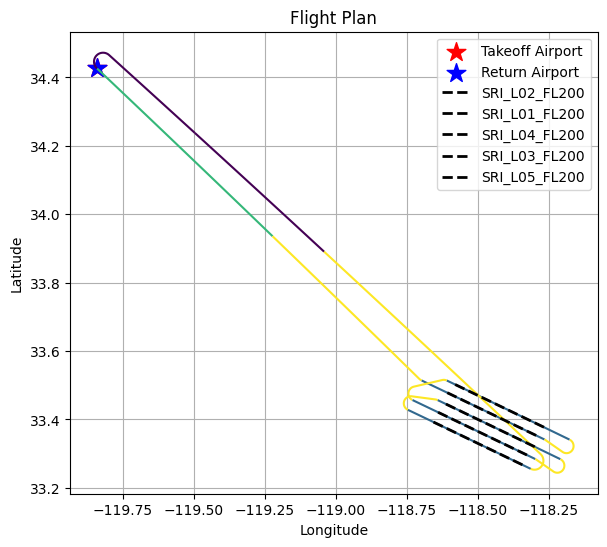

In [81]:
plot_flight_plan(
    flight_plan,
    departure_airport,
    return_airport,
    result["flight_sequence"],
)

### Altitude Profile

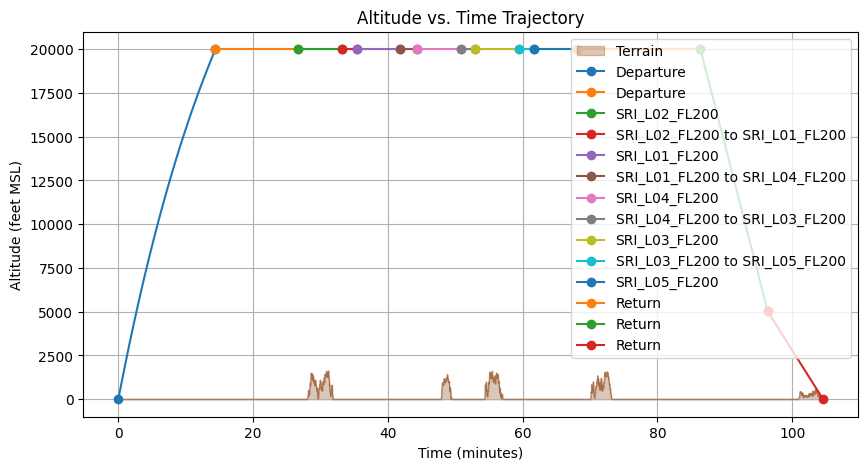

In [82]:
plot_altitude_trajectory(flight_plan, aircraft=aircraft)

### Interactive Map

An interactive Folium map with clickable flight lines.

In [83]:
m = map_flight_lines(
    result["flight_sequence"],
    center=(centroid.y, centroid.x),
    zoom_start=10,
)
m

## 9. Create Individual Flight Lines

For cases where you need to define flight lines manually (e.g., specific transects), HyPlan provides two factory methods.

In [84]:
# From a start point, length, and heading
transect = FlightLine.start_length_azimuth(
    lat1=34.0, lon1=-119.8,
    length=ureg.Quantity(30, "kilometer"),
    az=270.0,
    altitude_msl=ureg.Quantity(20000, "feet"),
    site_name="Coastal Transect",
)

print(f"{transect.site_name}:")
print(f"  Start: ({transect.lat1:.4f}, {transect.lon1:.4f})")
print(f"  End:   ({transect.lat2:.4f}, {transect.lon2:.4f})")
print(f"  Length: {transect.length.to(ureg.kilometer):.2f}")
print(f"  Heading: {transect.az12.magnitude:.1f}°")

Coastal Transect:
  Start: (34.0000, -119.8000)
  End:   (33.9996, -120.1247)
  Length: 30.00 kilometer
  Heading: 270.0°


In [85]:
# From a center point (extends equally in both directions)
centered = FlightLine.center_length_azimuth(
    lat=34.0, lon=-119.8,
    length=ureg.Quantity(30, "kilometer"),
    az=0.0,
    altitude_msl=ureg.Quantity(20000, "feet"),
    site_name="N-S Transect",
)

print(f"{centered.site_name}:")
print(f"  Start: ({centered.lat1:.4f}, {centered.lon1:.4f})")
print(f"  End:   ({centered.lat2:.4f}, {centered.lon2:.4f})")
print(f"  Center: ({(centered.lat1+centered.lat2)/2:.4f}, {(centered.lon1+centered.lon2)/2:.4f})")

N-S Transect:
  Start: (33.8648, -119.8000)
  End:   (34.1352, -119.8000)
  Center: (34.0000, -119.8000)


In [86]:
# Split a long line into segments
segments = transect.split_by_length(
    max_length=ureg.Quantity(10, "kilometer"),
    gap_length=ureg.Quantity(1, "kilometer"),
)
print(f"Split into {len(segments)} segments:")
for seg in segments:
    print(f"  {seg.site_name}: {seg.length.to(ureg.kilometer):.2f}")

Split into 3 segments:
  Coastal Transect_seg_0: 10.00 kilometer
  Coastal Transect_seg_1: 10.00 kilometer
  Coastal Transect_seg_2: 8.00 kilometer


## Summary

This tutorial demonstrated the core HyPlan workflow:

| Step | Function | Purpose |
|------|----------|---------|
| Instrument setup | `AVIRIS3()` | Define sensor characteristics |
| Aircraft setup | `DynamicAviation_B200()` | Define aircraft performance |
| Flight box | `box_around_polygon()` | Generate parallel flight lines |
| Solar check | `solar_threshold_times()` | Determine illumination windows |
| Airport search | `airports_within_radius()` | Find nearby airports |
| Optimization | `greedy_optimize()` | Order lines for efficiency |
| Flight plan | `compute_flight_plan()` | Detailed segment-by-segment plan |
| Visualization | `plot_flight_plan()`, `map_flight_lines()` | Maps and altitude profiles |

For more details, see the [HyPlan documentation](https://ryanpavlick.github.io/hyplan/).